# Climate Coding Challenge

Climate change is impacting the way people live around the world

## Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [1]:
%store -r

You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [2]:
### import libraries

### handle local data
import earthpy

###deal with tabular data
import pandas as pd 

### libraries for visualization

import holoviews as hv
import hvplot.pandas
import hvplot


## Step 2: Plot your results

### Step 2A: Plot the temperature column vs time to explore the data
Plotting in Python is easy, but not quite this easy:

<Axes: xlabel='DATE'>

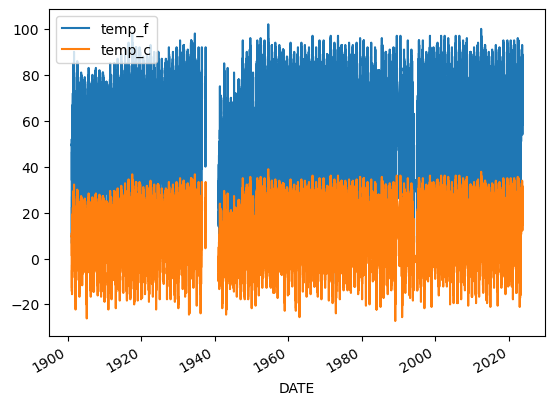

In [3]:
temp_units_df.plot()

Looks like we have *both* temperature units on the same plot, and it’s
hard to see what it is because it’s missing labels!

> ****Label your plot****
>
> <figure>
> <img src="https://imgs.xkcd.com/comics/convincing.png"
> alt="Source: https://xkcd.com/833" />
> <figcaption aria-hidden="true">Source: https://xkcd.com/833</figcaption>
> </figure>
>
> Make sure each plot has:
>
> -   A title that explains where and when the data are from
> -   x- and y- axis labels with **units** where appropriate
> -   A legend where appropriate

When plotting in Python, you’ll always need to add some instructions on
labels and how you want your plot to look.

<Axes: title={'center': 'Daily Temperature in Boulder, CO'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

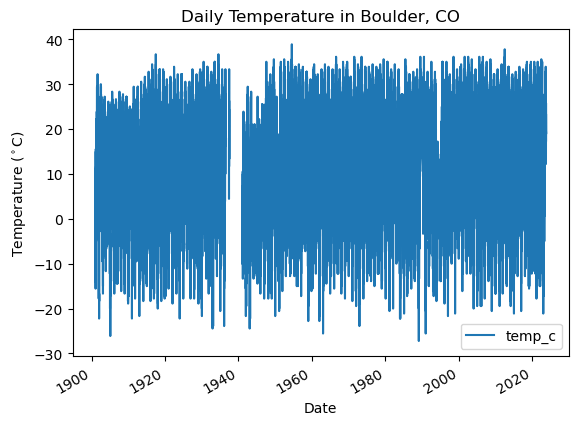

In [4]:
### plot the data using .plot
temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Boulder, CO',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)')

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try it yourself</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Change <code>climate_u_df</code> to <strong>your</strong>
<code>DataFrame</code> name.</li>
<li>Change <code>y=</code> to the name of your
<strong>temperature</strong> column.</li>
<li>Use the <code>title</code>, <code>ylabel</code>, and
<code>xlabel</code> parameters to add key text to your plot.</li>
<li>Adjust the size of your figure using <code>figsize=(x,y)</code>
where <code>x</code> is figure width and <code>y</code> is figure
height</li>
</ol></div></div>

> **Tip**
>
> Labels have to be a *type* in Python called a **string**. You can make
> a string by putting quotes around your label, just like the column
> names in the sample code (eg `y='temperature'`).

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-extra"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill"><strong>Looking for an extra challenge?</strong></div></div><div class="callout-body-container callout-body"><p>There are many other things you can do to customize your plot. Take a
look at the <a
href="https://pandas.pydata.org/docs/user_guide/visualization.html">pandas
plotting galleries</a> and the <a
href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html">documentation
of plot</a> to see if there’s other changes you want to make to your
plot. Some possibilities include:</p>
<ul>
<li>Remove the legend since there’s only one data series</li>
<li>Increase the figure size</li>
<li>Increase the font size</li>
<li>Change the colors</li>
<li>Use a bar graph instead (usually we use lines for time series, but
since this is annual it could go either way)</li>
<li>Add a trend line</li>
</ul>
<p>Not sure how to do any of these? Try searching the Stack Overflow or asking on the GitHub discussion board!</p></div></div>

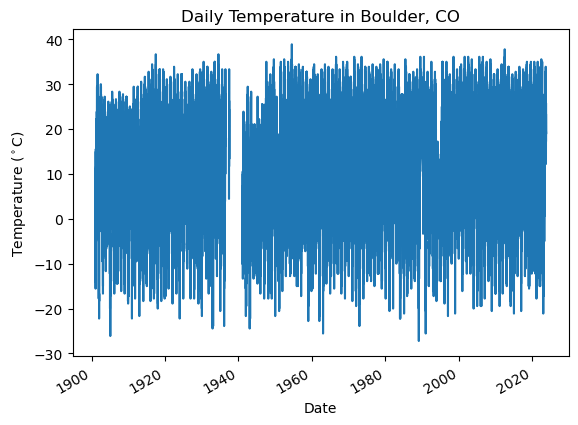

In [5]:
### plot without the legend
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Boulder, CO',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)')
no_legend.legend().remove()

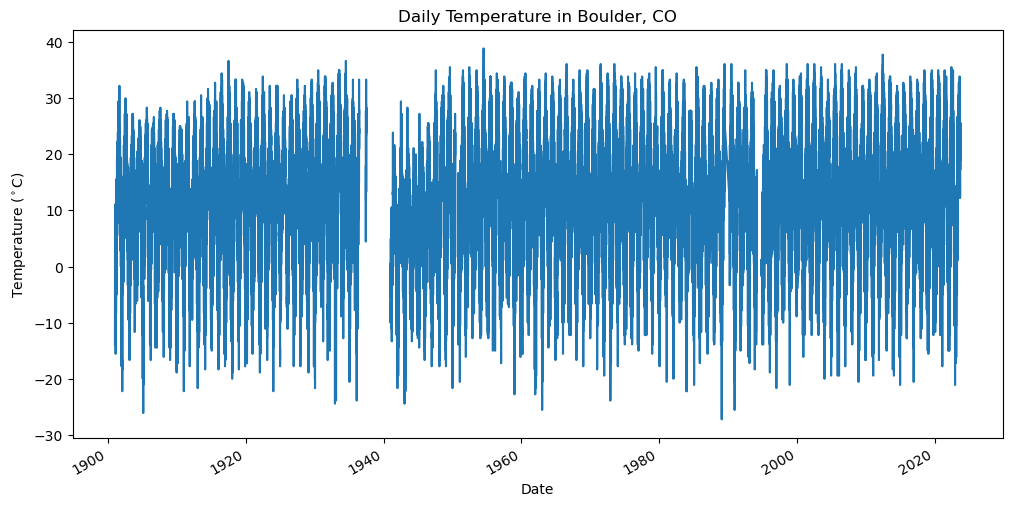

In [6]:
### change the figure size
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Boulder, CO',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize = (12,6))
no_legend.legend().remove()

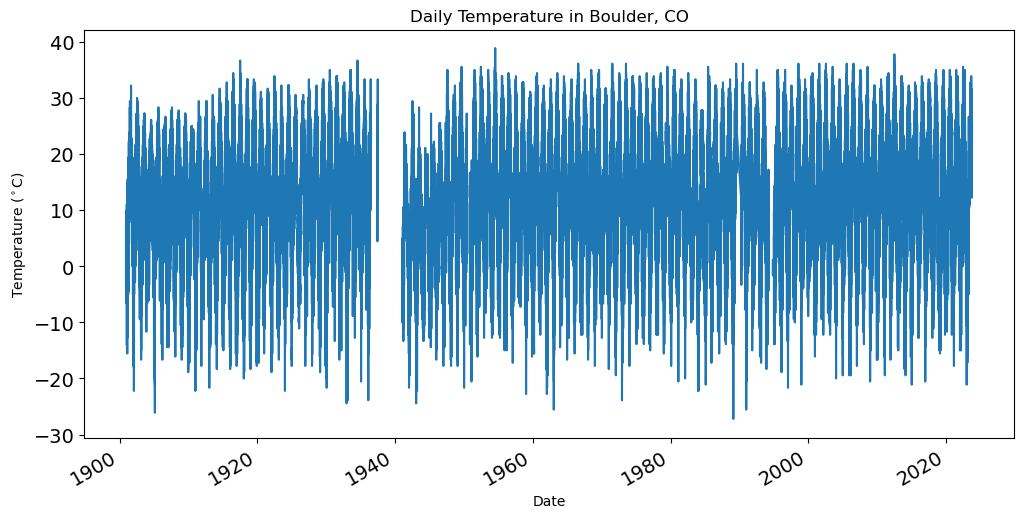

In [7]:
### change the font size
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Boulder, CO',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize = (12,6),
    fontsize = 14)
no_legend.legend().remove()

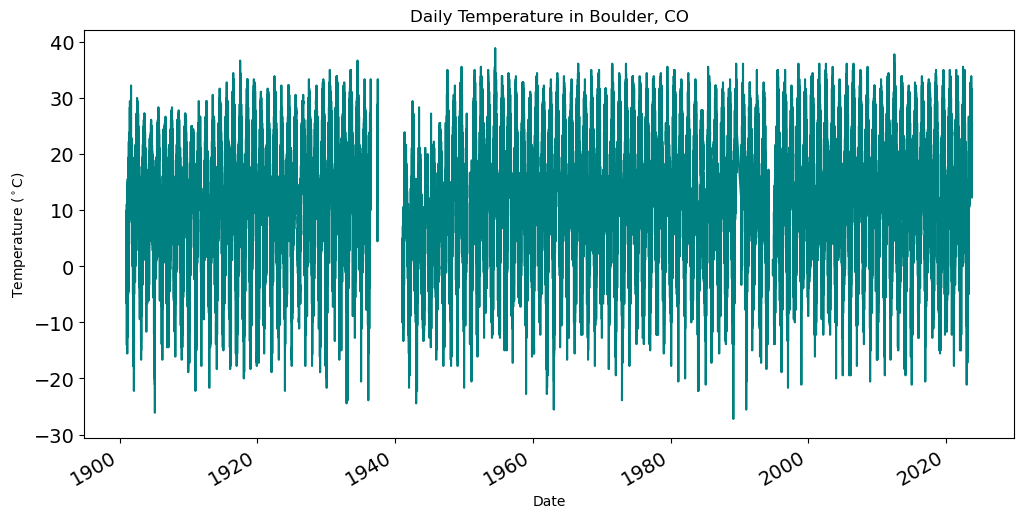

In [8]:
### change the color
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Boulder, CO',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize = (12,6),
    fontsize = 14,
    color = 'teal')
no_legend.legend().remove()

### Step 2B: Clean up time series plots by resampling

You may notice that your plot looks a little “fuzzy”. This happens when Python is trying to plot a value for every date, but the resolution of the image is too low to actually do that. You can address this issue by **resampling** the data, or summarizing it over a time period of your choice. In this case, we will resample annually, giving us one data point per year.

In [9]:
### Get mean Average Temp
annual_temp_df = (
    ### resample data frame
    temp_units_df

    ### sample annually
    .resample('YS')

    ###calculate mean
    .mean()
)

annual_temp_df

,temp_f,temp_c
DATE,,
1893-01-01,NaN,NaN
1894-01-01,NaN,NaN
1895-01-01,NaN,NaN
1896-01-01,NaN,NaN
1897-01-01,NaN,NaN
...,...,...
2019-01-01,54.426997,12.459443
2020-01-01,57.691460,14.273033
2021-01-01,57.538462,14.188034


<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try it yourself</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Set the frequency of your final data by replacing
<code>DT_OFFSET</code>with a <strong>Datetime Offset Code</strong>.
Check out the table in the <a
href="https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects">pandas
datetime documentation</a> to find the one you want (we recommend the
start of the year).</li>
<li>Choose how to summarize each year of data by replacing
<code>agg_method_here</code> with a method that will calculate the
<strong>average annual value</strong>. Check out the <a
href="https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#basics">pandas
resampling documentation</a> for a list of common built-in options.</li>
<li>Add descriptive comments to the code so the next person reading it knows what it is doing.</li>
</ol></div></div>

### Step 2C: Plot the annual data
<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill"></div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Try plotting your new DataFrame in the cell below. Can you see what is going on more clearly now? Don’t forget to adjust your labels!</li>
<li>If you write your code on one line, it will most likely be to long to read without scrolling. Make sure you are following <a
href="https://peps.python.org/pep-0008/">PEP-8 style guidelines</a> by keeping your lines less than 80 characters long. If you are working in GitHub Codespaces, we have set you up with a vertical guide that is between 79 and 80 characters – make sure your code doesn’t go past it!</li>
<li>PEP-8 also suggests aligning any function parameters that are too long. See some examples below for what to do and what not to do.</li>
</ol></div></div>

**PEP=8 tips:** Following the PEP-8 style guide is important because it makes your code easy for you and other collaborators to read. When you are splitting function calls across multiple lines, your code should look like this:

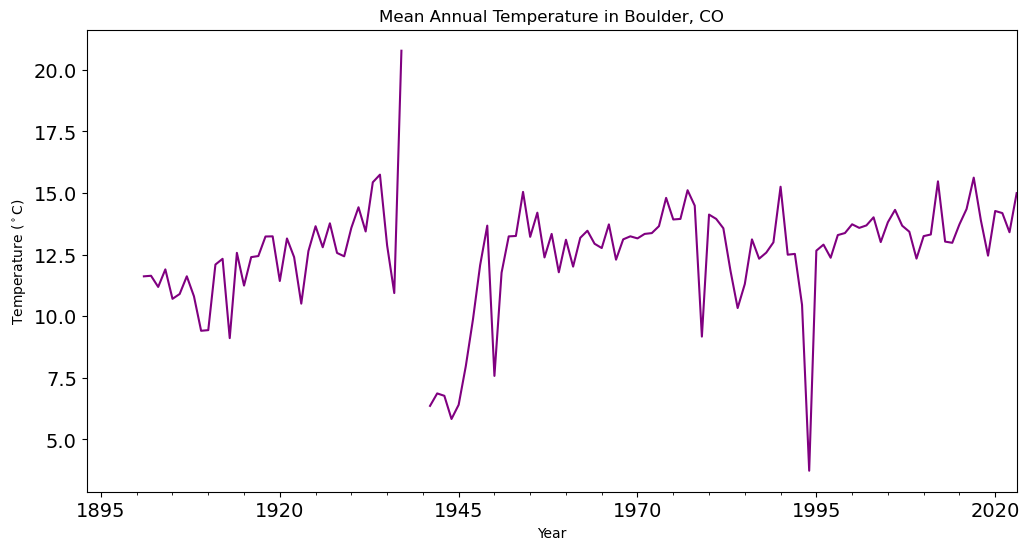

In [10]:
### plot mean annual temperatures

no_legend=annual_temp_df.plot (
    y = 'temp_c',
    title = 'Mean Annual Temperature in Boulder, CO',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)',
    fontsize = 14, 
    color = 'purple',
    figsize = (12,6)
)
no_legend.legend().remove()


Or maybe like this:

Go ahead and plot the data if you haven't already:

### Reflect and Respond #1: Interpret your plot  
1. Create a new Markdown cell below your annual temperature plot.
2. Using a **bulleted** list in Markdown, write down 2 things you notice about the data. What **physical phenomena** or **data anomaly** could be causing each one?

Two things I notice about my data
* Around 1937 there is a really high spike in the data and then there is missing data for about 5 years and then in about 1943 the data point is noticeably low. Interestingly this time period of missing data seems to overlap with WWII. I read that during the war weather information was censored which explains this gap in weather. Additionally, we can infer that for the years on either side of this gap data was only collected for a portion of the year which would skew the mean. 
* Overall, the data does appear to have a slight increase overtime. This would be explained by climate change. Additionally, there appear to be larger spikes in temperature from year to year in the 1990s and twenty first centure which would be explained by global weirding which is the idea that temperatures are not only rising over time but are also becoming more eratic and "weird".

## Step 3: Make an interactive plot
You can use the `.hvplot()` method with similar arguments to create an interactive plot:

1. Copy your plotting code into the cell below  
2. Replace `.plot` in your code with `.hvplot`
3. Check that your code follows PEP-8 guidelines

Now, you should be able to hover over data points and see their values!

In [11]:
hvplot.extension("bokeh")

In [12]:
### plot the annual data interactively
annual_temp_plot=annual_temp_df.hvplot (
    y = 'temp_c',
    title = 'Mean Annual Temperature in Boulder, CO',
    xlabel = 'Year',
    ylabel = 'Temperature (degrees C)',
    fontsize = 14, 
    color = 'purple',
)

### view the plot
annual_temp_plot



:Curve   [DATE]   (temp_c)

### Reflect and Respond #2: Explore the data
1. Create a new Markdown cell below your interactive annual temperature plot.
2. Hover over the lowest point on your plot. What is the minimum mean annual temperature?  
3. Hover over the highest point on your plot. What is the maximum mean annual temperature?  

The minimum mean annual temperature is 3.731 C (38.7 F) in 1994 and the maximum mean annual temperature is 20.788 C (69.4 F) in 1937.

## Step 4: Save your work
You will need to save your analyses and plots to tell others about what you find.

Just like with any other type of object in Python, if you want to
reuse your work, you need to give it a name.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill"></div></div><div class="callout-body-container callout-body">
<ol type="1">
<li>Go back to your <code>hvplot</code> code, and give your plot a name
by assigning it to a variable. HINT: if you still want your plot to
display in your notebook, make sure to <strong>call</strong> its name at
the end of the cell.</li>
<li>Replace <code>my_plot</code> with the name you gave to your
plot.</li>
<li>Replace <code>'my_plot.html'</code> with the name you want for your
plot. If you change the file extension, <code>.html</code>, to
<code>.png</code>, you will get an image instead of an interactive
webpage, provided you have the necessary libraries installed.</li>
</ol>
<p>Once you run the code, you should see your saved plot in your files –
go ahead and open it up.</p></div></div>

> **Warning**
>
> If you are working in GitHub Codespaces, right-click on your file and
> download it to view it.

In [13]:
hv.save(annual_temp_plot, 'annual_temp_plot.html')

# Wrap up Steps 2-4

Don’t forget to store your variables so you can use them in other
notebooks! Replace `var1` and `var2` with the variable you want to save,
separated by spaces.

In [14]:
%store annual_temp_df

Stored 'annual_temp_df' (DataFrame)


Finally, be sure to `Restart` and `Run all` to make sure your notebook
works all the way through!